In [2]:
# ============================================================
# CELL 1 — Imports, reproducibility, and GPU check
# ============================================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import time
import random

# Fixed random seed required by Assignment 3
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Random seed:", SEED)

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("GPU detected:", gpus)
else:
    print("WARNING: No GPU detected. Go to Runtime > Change runtime type > T4 GPU.")

TensorFlow version: 2.20.0
Random seed: 42
GPU detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# ============================================================
# CELL 2 — Load MNIST
# ============================================================

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Original MNIST shapes:")
print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Test images:", x_test.shape)
print("Test labels:", y_test.shape)

print("\nPixel range:")
print("Min:", x_train.min())
print("Max:", x_train.max())

print("\nClasses:", np.unique(y_train))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Original MNIST shapes:
Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)

Pixel range:
Min: 0
Max: 255

Classes: [0 1 2 3 4 5 6 7 8 9]


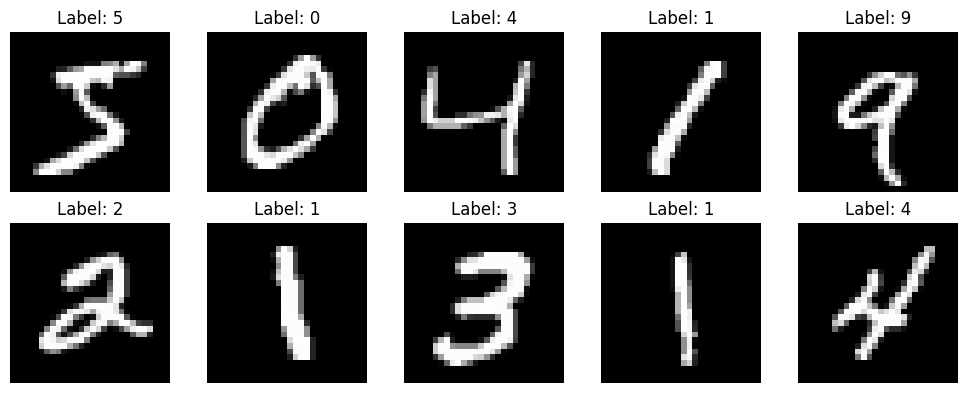

In [4]:
# ============================================================
# CELL 3 — Visualize raw MNIST samples
# ============================================================

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
# ============================================================
# CELL 4 — Scale and normalize MNIST
# ============================================================

MNIST_MEAN = 0.1307
MNIST_STD = 0.3081

# Convert uint8 [0,255] -> float32 [0,1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Apply MNIST normalization
x_train = (x_train - MNIST_MEAN) / MNIST_STD
x_test = (x_test - MNIST_MEAN) / MNIST_STD

print("Normalization used:")
print("Mean =", MNIST_MEAN)
print("Standard deviation =", MNIST_STD)

print("\nAfter normalization:")
print("Training min:", x_train.min())
print("Training max:", x_train.max())

Normalization used:
Mean = 0.1307
Standard deviation = 0.3081

After normalization:
Training min: -0.42421296
Training max: 2.8214867


In [6]:
# ============================================================
# CELL 5 — Zero-pad MNIST to 32x32 and add channel dimension
# ============================================================

# Pad 2 pixels on top, bottom, left, and right
x_train = np.pad(
    x_train,
    ((0, 0), (2, 2), (2, 2)),
    mode="constant",
    constant_values=0
)

x_test = np.pad(
    x_test,
    ((0, 0), (2, 2), (2, 2)),
    mode="constant",
    constant_values=0
)

# Add grayscale channel dimension
# (N, 32, 32) -> (N, 32, 32, 1)
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print("Final input shapes:")
print("x_train:", x_train.shape)
print("x_test :", x_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

Final input shapes:
x_train: (60000, 32, 32, 1)
x_test : (10000, 32, 32, 1)
y_train: (60000,)
y_test : (10000,)


In [7]:
# ============================================================
# CELL 6 — Trainable LeNet subsampling layer
# Same implementation used in Lab 2
# ============================================================

class TrainableSubsampling(tf.keras.layers.Layer):

    def build(self, input_shape):

        channels = input_shape[-1]

        # One trainable coefficient per feature map
        self.alpha = self.add_weight(
            name="alpha",
            shape=(channels,),
            initializer="ones",
            trainable=True
        )

        # One trainable bias per feature map
        self.beta = self.add_weight(
            name="beta",
            shape=(channels,),
            initializer="zeros",
            trainable=True
        )

    def call(self, inputs):

        # Average over non-overlapping 2x2 regions
        x = tf.nn.avg_pool2d(
            inputs,
            ksize=2,
            strides=2,
            padding="VALID"
        )

        # Convert average into sum
        x = x * 4.0

        # Trainable scaling and bias
        x = x * self.alpha + self.beta

        # LeNet-style subsampling activation
        return tf.nn.sigmoid(x)

print("TrainableSubsampling layer defined successfully.")

TrainableSubsampling layer defined successfully.


In [8]:
# ============================================================
# CELL 7 — Build LeNet-5 for MNIST
# ============================================================

def build_lenet_mnist():

    model = tf.keras.Sequential([

        # Assignment 3 adaptation:
        # 32x32 GRAYSCALE instead of 32x32 RGB
        tf.keras.layers.Input(shape=(32, 32, 1)),

        # C1: 32x32x1 -> 28x28x6
        tf.keras.layers.Conv2D(
            filters=6,
            kernel_size=(5, 5),
            strides=(1, 1),
            padding="valid",
            activation="tanh"
        ),

        # S2: 28x28x6 -> 14x14x6
        TrainableSubsampling(),

        # C3: 14x14x6 -> 10x10x16
        tf.keras.layers.Conv2D(
            filters=16,
            kernel_size=(5, 5),
            strides=(1, 1),
            padding="valid",
            activation="tanh"
        ),

        # S4: 10x10x16 -> 5x5x16
        TrainableSubsampling(),

        # C5: 5x5x16 -> 1x1x120
        tf.keras.layers.Conv2D(
            filters=120,
            kernel_size=(5, 5),
            strides=(1, 1),
            padding="valid",
            activation="tanh"
        ),

        # F6
        tf.keras.layers.Flatten(),

        tf.keras.layers.Dense(
            units=84,
            activation="tanh"
        ),

        # MNIST has 10 classes: digits 0-9
        tf.keras.layers.Dense(
            units=10,
            activation="softmax"
        )
    ])

    return model


lenet_mnist = build_lenet_mnist()

print("LeNet-5 for MNIST created successfully.")

LeNet-5 for MNIST created successfully.


In [9]:
# ============================================================
# CELL 8 — Model summary and parameter count
# ============================================================

lenet_mnist.summary()

print("\nTotal trainable parameters:")
print(lenet_mnist.count_params())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ trainable_subsampling           │ (None, 14, 14, 6)      │            12 │
│ (TrainableSubsampling)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ trainable_subsampling_1         │ (None, 5, 5, 16)       │            32 │
│ (TrainableSubsampling)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 1, 1, 120)      │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,750 (241.21 KB)

 Trainable params: 61,750 (241.21 KB)

 Non-trainable params: 0 (0.00 B)


Total trainable parameters:
61750


In [10]:
# ============================================================
# CELL 9 — Compile LeNet-5
# ============================================================

lenet_mnist.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=[
        "accuracy"
    ]
)

print("Model compiled successfully.")

Model compiled successfully.


In [11]:
# ============================================================
# CELL 10 — Callback to measure training time per epoch
# ============================================================

class EpochTimeCallback(tf.keras.callbacks.Callback):

    def on_train_begin(self, logs=None):
        self.epoch_times = []

    def on_epoch_begin(self, epoch, logs=None):
        self.start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        elapsed = time.time() - self.start_time
        self.epoch_times.append(elapsed)

        print(
            f"\nEpoch {epoch + 1} training time: "
            f"{elapsed:.2f} seconds"
        )


time_callback = EpochTimeCallback()

print("Epoch timer ready.")

Epoch timer ready.


In [12]:
# ============================================================
# CELL 11 — Train LeNet-5 on MNIST
# ============================================================

EPOCHS = 10
BATCH_SIZE = 128

history = lenet_mnist.fit(
    x_train,
    y_train,

    epochs=EPOCHS,
    batch_size=BATCH_SIZE,

    validation_split=0.1,

    callbacks=[time_callback],

    verbose=1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7503 - loss: 0.8147
Epoch 1 training time: 10.74 seconds
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.8737 - loss: 0.4208 - val_accuracy: 0.9577 - val_loss: 0.1359
Epoch 2/10
410/422 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9584 - loss: 0.1348
Epoch 2 training time: 2.68 seconds
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9641 - loss: 0.1170 - val_accuracy: 0.9770 - val_loss: 0.0777
Epoch 3/10
413/422 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9735 - loss: 0.0873
Epoch 3 training time: 1.70 seconds
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9745 - loss: 0.0829 - val_accuracy: 0.9805 - val_loss: 0.0653
Epoch 4/10
416/422 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9802 - loss: 0.0671
Epoch 4 training time: 2.15 seconds
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9798 - loss: 0.0660 - val_accuracy: 0.9832 - val_loss: 0.0593
Epoch 5/10
420/422 ━━━━━━━━━━━━━━━━━━━━ 0

In [13]:
# ============================================================
# CELL 12 — Test-set evaluation
# ============================================================

test_loss, test_accuracy = lenet_mnist.evaluate(
    x_test,
    y_test,
    verbose=1
)

print("\n========== TASK 1 TEST RESULTS ==========")

print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy * 100:.2f}%")
print(f"Parameters:    {lenet_mnist.count_params():,}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9852 - loss: 0.0449

========== TASK 1 TEST RESULTS ==========
Test loss:     0.0449
Test accuracy: 98.52%
Parameters:    61,750


In [14]:
# ============================================================
# CELL 13 — Epoch training-time results
# ============================================================

epoch_times = time_callback.epoch_times

print("========== TRAINING TIME ==========")

for i, t in enumerate(epoch_times, start=1):
    print(f"Epoch {i:2d}: {t:.2f} seconds")

average_epoch_time = np.mean(epoch_times)

print("-----------------------------------")
print(f"Average epoch time: {average_epoch_time:.2f} seconds")

========== TRAINING TIME ==========
Epoch  1: 10.74 seconds
Epoch  2: 2.68 seconds
Epoch  3: 1.70 seconds
Epoch  4: 2.15 seconds
Epoch  5: 2.16 seconds
Epoch  6: 1.73 seconds
Epoch  7: 1.73 seconds
Epoch  8: 1.77 seconds
Epoch  9: 1.76 seconds
Epoch 10: 1.93 seconds
-----------------------------------
Average epoch time: 2.84 seconds


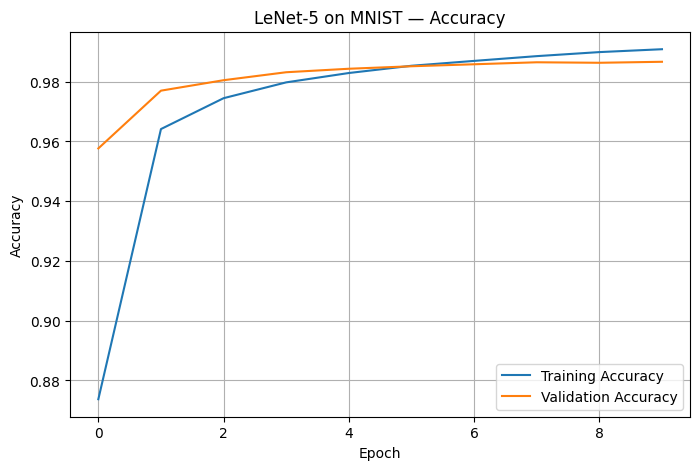

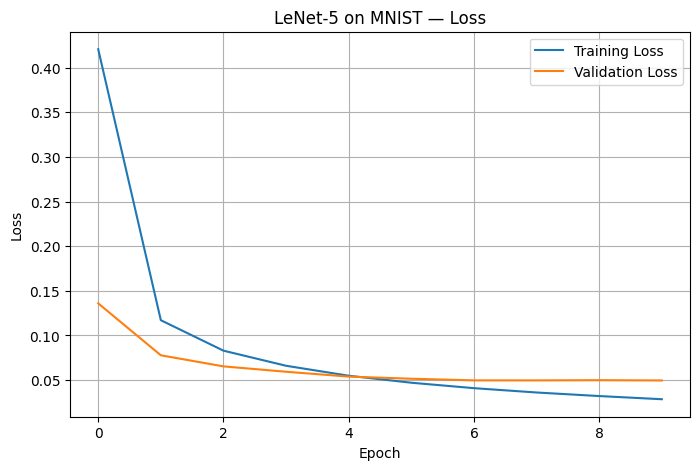

In [15]:
# ============================================================
# CELL 14 — Plot training curves
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LeNet-5 on MNIST — Accuracy")
plt.legend()
plt.grid()

plt.show()


plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LeNet-5 on MNIST — Loss")
plt.legend()
plt.grid()

plt.show()

In [17]:
# ============================================================
# CELL 15 — Save trained model
# ============================================================
lenet_mnist.save("lenet5_mnist.keras", zipped=True)

print("Model saved successfully:")


Model saved successfully:


In [18]:
# ============================================================
# CELL 16 — Verify saved model
# ============================================================

loaded_model = tf.keras.models.load_model(
    "lenet5_mnist.keras",
    custom_objects={
        "TrainableSubsampling": TrainableSubsampling
    }
)

loaded_loss, loaded_accuracy = loaded_model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Saved model loaded successfully.")
print(f"Loaded model accuracy: {loaded_accuracy * 100:.2f}%")

Saved model loaded successfully.
Loaded model accuracy: 98.52%


In [ ]:
# ============================================================
# CELL 17 — Download trained model
# ============================================================

from google.colab import files

files.download("lenet5_mnist.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

OpenCV version: 4.14.0


Saving WhatsApp Image 2026-10-02 at 12.59.19 PM (1).jpeg to WhatsApp Image 2026-10-02 at 12.59.19 PM (1) (1).jpeg
Uploaded file: WhatsApp Image 2026-10-02 at 12.59.19 PM (1) (1).jpeg
ROI shape: (598, 710, 3)


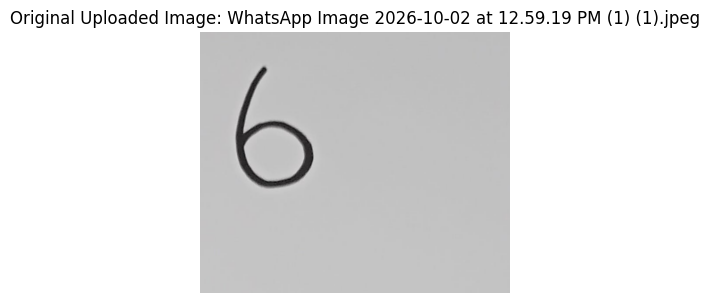

preprocess() defined successfully.
Final tensor shape: (1, 32, 32, 1)
Final tensor dtype: float32
Final tensor min: -0.42421296
Final tensor max: 2.8214867


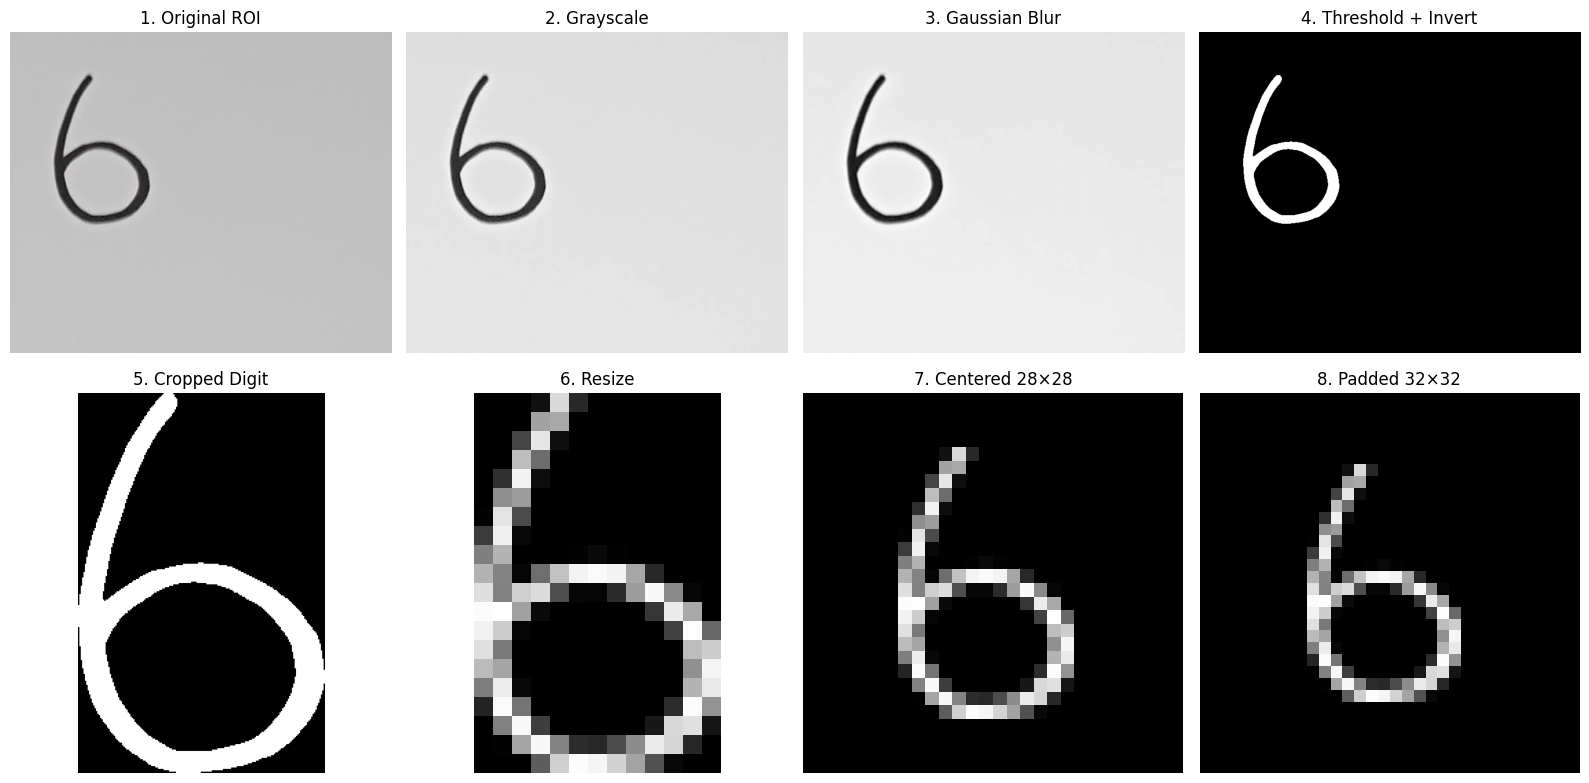

Predicted digit: 6
Confidence: 83.29%


In [ ]:

# ============================================================
# TASK 2
# OpenCV import
# Upload and display any digit image
# ============================================================

import cv2

print("OpenCV version:", cv2.__version__)

from google.colab import files

# Upload an image
uploaded = files.upload()

# Get the actual uploaded filename
filename = next(iter(uploaded))

print("Uploaded file:", filename)

# Read uploaded image
roi = cv2.imread(filename)

# Check that image was loaded successfully
if roi is None:
    raise ValueError(f"Could not read image: {filename}")

print("ROI shape:", roi.shape)

# Display original image
plt.figure(figsize=(4, 4))

plt.imshow(
    cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)
)

plt.title(f"Original Uploaded Image: {filename}")
plt.axis("off")

plt.show()

# ============================================================
# TASK 2
# Preprocessing pipeline
# ============================================================

MNIST_MEAN = 0.1307
MNIST_STD = 0.3081


def preprocess(roi):

    # --------------------------------------------------------
    # STEP 1 — Grayscale + Gaussian blur
    # --------------------------------------------------------

    gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)

    # Small Gaussian blur to reduce camera noise
    blurred = cv2.GaussianBlur(
        gray,
        (5, 5),
        0
    )


    # --------------------------------------------------------
    # STEP 2 — Threshold + invert
    # --------------------------------------------------------

    _, thresholded = cv2.threshold(
        blurred,
        0,
        255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    # Optional dilation to thicken thin strokes
    kernel = np.ones((2, 2), np.uint8)

    thresholded = cv2.dilate(
        thresholded,
        kernel,
        iterations=1
    )


    # --------------------------------------------------------
    # STEP 3 — Find and crop the digit
    # --------------------------------------------------------

    contours, _ = cv2.findContours(
        thresholded,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:
        raise ValueError("No digit contour was found.")

    # Largest contour = assumed to be the digit
    largest_contour = max(
        contours,
        key=cv2.contourArea
    )

    x, y, w, h = cv2.boundingRect(
        largest_contour
    )

    cropped = thresholded[
        y:y+h,
        x:x+w
    ]


    # --------------------------------------------------------
    # STEP 4 — Resize and centre
    # --------------------------------------------------------

    # Larger side should become 20 pixels
    scale = 20.0 / max(w, h)

    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    resized = cv2.resize(
        cropped,
        (new_w, new_h),
        interpolation=cv2.INTER_AREA
    )

    # Create 28x28 black image
    centered = np.zeros(
        (28, 28),
        dtype=np.uint8
    )

    # Calculate position to place digit in center
    start_x = (28 - new_w) // 2
    start_y = (28 - new_h) // 2

    centered[
        start_y:start_y + new_h,
        start_x:start_x + new_w
    ] = resized

    # Pad 28x28 -> 32x32
    padded = np.pad(
        centered,
        ((2, 2), (2, 2)),
        mode="constant",
        constant_values=0
    )


    # --------------------------------------------------------
    # STEP 5 — Convert to tensor
    # --------------------------------------------------------

    # uint8 [0,255] -> float32 [0,1]
    normalized = padded.astype("float32") / 255.0

    # Same normalization used during Task 1
    normalized = (
        normalized - MNIST_MEAN
    ) / MNIST_STD

    # Add channel dimension:
    # (32,32) -> (32,32,1)
    tensor = np.expand_dims(
        normalized,
        axis=-1
    )

    # Add batch dimension:
    # (32,32,1) -> (1,32,32,1)
    tensor = np.expand_dims(
        tensor,
        axis=0
    )

    # Return final tensor + intermediate results
    return tensor, {
        "gray": gray,
        "blurred": blurred,
        "thresholded": thresholded,
        "cropped": cropped,
        "resized": resized,
        "centered_28x28": centered,
        "padded_32x32": padded,
        "normalized": normalized
    }


print("preprocess() defined successfully.")

# ============================================================
# TASK 2
# Run preprocessing
# ============================================================

tensor, steps = preprocess(roi)

print("Final tensor shape:", tensor.shape)
print("Final tensor dtype:", tensor.dtype)
print("Final tensor min:", tensor.min())
print("Final tensor max:", tensor.max())

# ============================================================
# TASK 2 — CELL 4
# Visualize preprocessing pipeline
# ============================================================

plt.figure(figsize=(16, 8))

# Original
plt.subplot(2, 4, 1)
plt.imshow(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
plt.title("1. Original ROI")
plt.axis("off")

# Grayscale
plt.subplot(2, 4, 2)
plt.imshow(steps["gray"], cmap="gray")
plt.title("2. Grayscale")
plt.axis("off")

# Blur
plt.subplot(2, 4, 3)
plt.imshow(steps["blurred"], cmap="gray")
plt.title("3. Gaussian Blur")
plt.axis("off")

# Threshold
plt.subplot(2, 4, 4)
plt.imshow(steps["thresholded"], cmap="gray")
plt.title("4. Threshold + Invert")
plt.axis("off")

# Crop
plt.subplot(2, 4, 5)
plt.imshow(steps["cropped"], cmap="gray")
plt.title("5. Cropped Digit")
plt.axis("off")

# Resize
plt.subplot(2, 4, 6)
plt.imshow(steps["resized"], cmap="gray")
plt.title("6. Resize")
plt.axis("off")

# Center
plt.subplot(2, 4, 7)
plt.imshow(steps["centered_28x28"], cmap="gray")
plt.title("7. Centered 28×28")
plt.axis("off")

# Pad
plt.subplot(2, 4, 8)
plt.imshow(steps["padded_32x32"], cmap="gray")
plt.title("8. Padded 32×32")
plt.axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# TASK 2
# Test the preprocessed digit with LeNet
# ============================================================

prediction = lenet_mnist.predict(
    tensor,
    verbose=0
)

predicted_digit = np.argmax(prediction[0])

confidence = np.max(prediction[0])

print("Predicted digit:", predicted_digit)
print(f"Confidence: {confidence * 100:.2f}%")